# P09 – NLP-Based Financial Sentiment Analysis & Fusion Pipeline

1. **Step 1** – Fine-tune FinBERT on Financial PhraseBank
2. **Step 2** – Load FNSPID news dataset & score with FinBERT
3. **Step 3** – Fuse sentiment with technical features (FusionLSTM)
4. **Step 4** – Compare Baseline vs Fusion LSTM

---
## Step 1 – FinBERT Fine-Tuning
### 1.1 Imports & NLTK

In [36]:
import os, torch, numpy as np, pandas as pd, nltk
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from collections import Counter

print("Downloading NLTK data...")
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

True

### 1.2 Load Financial PhraseBank

In [37]:
print("Loading Financial PhraseBank from mteb/financial_phrasebank...")
try:
    dataset = load_dataset("mteb/financial_phrasebank", "sentences_allagree", split="train")
    df = pd.DataFrame(dataset)
    if 'text' in df.columns:
        df.rename(columns={'text': 'sentence'}, inplace=True)
except Exception as e:
    print(f"Error: {e}"); raise

label_map = {0: "negative", 1: "neutral", 2: "positive"}
df['label_name'] = df['label'].map(label_map)
print(f"Dataset shape: {df.shape}")
df['label_name'].value_counts()

Loading Financial PhraseBank from mteb/financial_phrasebank...
Dataset shape: (1129, 3)


label_name
neutral     692
positive    285
negative    152
Name: count, dtype: int64

### 1.3 POS-Tagging Analysis

In [38]:
def analyze_pos(texts, pos_prefix):
    words = []
    for text in texts:
        tokens = nltk.word_tokenize(text.lower())
        tags = nltk.pos_tag(tokens)
        words.extend([word for word, tag in tags if tag.startswith(pos_prefix) and word.isalpha()])
    return Counter(words).most_common(10)

pos_texts = df[df['label'] == 2]['sentence'].tolist()
neg_texts = df[df['label'] == 0]['sentence'].tolist()

print("Top 10 Adjectives (JJ) in POSITIVE headlines:")
print(analyze_pos(pos_texts, 'JJ'))
print("\nTop 10 Adjectives (JJ) in NEGATIVE headlines:")
print(analyze_pos(neg_texts, 'JJ'))
print("\nTop 10 Verbs (VB) in POSITIVE headlines:")
print(analyze_pos(pos_texts, 'VB'))
print("\nTop 10 Verbs (VB) in NEGATIVE headlines:")
print(analyze_pos(neg_texts, 'VB'))

Top 10 Adjectives (JJ) in POSITIVE headlines:
[('net', 78), ('eur', 58), ('finnish', 56), ('corresponding', 29), ('first', 21), ('same', 17), ('second', 15), ('last', 14), ('third', 12), ('usd', 10)]

Top 10 Adjectives (JJ) in NEGATIVE headlines:
[('eur', 52), ('net', 43), ('finnish', 34), ('corresponding', 19), ('first', 18), ('usd', 8), ('second', 8), ('pretax', 8), ('same', 7), ('third', 7)]

Top 10 Verbs (VB) in POSITIVE headlines:
[('eur', 68), ('said', 57), ('rose', 41), ('increased', 37), ('compared', 32), ('has', 28), ('was', 21), ('grew', 16), ('won', 16), ('is', 14)]

Top 10 Verbs (VB) in NEGATIVE headlines:
[('eur', 32), ('decreased', 30), ('compared', 21), ('said', 21), ('was', 17), ('fell', 17), ('totalled', 9), ('euro', 8), ('be', 7), ('slipped', 7)]


### 1.4 Train/Val Split & Tokenization

In [39]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['sentence'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42, stratify=df['label'])

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

class FinancialDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings; self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx]); return item
    def __len__(self): return len(self.labels)

train_dataset = FinancialDataset(train_encodings, train_labels)
val_dataset = FinancialDataset(val_encodings, val_labels)
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

Train: 903, Val: 226


### 1.5 Fine-Tuning

In [40]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3, ignore_mismatched_sizes=True)

def compute_metrics(pred):
    labels = pred.label_ids; preds = pred.predictions.argmax(-1)
    return {'accuracy': accuracy_score(labels, preds), 'f1': f1_score(labels, preds, average='weighted')}

training_args = TrainingArguments(
    output_dir='./finbert-finetuned', num_train_epochs=3,
    per_device_train_batch_size=16, per_device_eval_batch_size=64,
    warmup_steps=100, weight_decay=0.01, logging_dir='./logs', logging_steps=50,
    eval_strategy="epoch", save_strategy="epoch", load_best_model_at_end=True, report_to="none")

trainer = Trainer(model=model, args=training_args, train_dataset=train_dataset,
                  eval_dataset=val_dataset, compute_metrics=compute_metrics)
print("Starting Fine-tuning...")
trainer.train()

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 14331.58it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting Fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.975909,0.412015,0.845133,0.816784
2,0.325196,0.163687,0.942478,0.943063
3,0.099998,0.135730,0.951327,0.951669


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.43it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=171, training_loss=0.7065645010150664, metrics={'train_runtime': 1195.9859, 'train_samples_per_second': 2.265, 'train_steps_per_second': 0.143, 'total_flos': 107194564734642.0, 'train_loss': 0.7065645010150664, 'epoch': 3.0})

### 1.6 Evaluation & Confusion Matrix


Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90        30
     Neutral       0.99      0.96      0.97       139
    Positive       0.90      0.95      0.92        57

    accuracy                           0.95       226
   macro avg       0.93      0.94      0.93       226
weighted avg       0.95      0.95      0.95       226



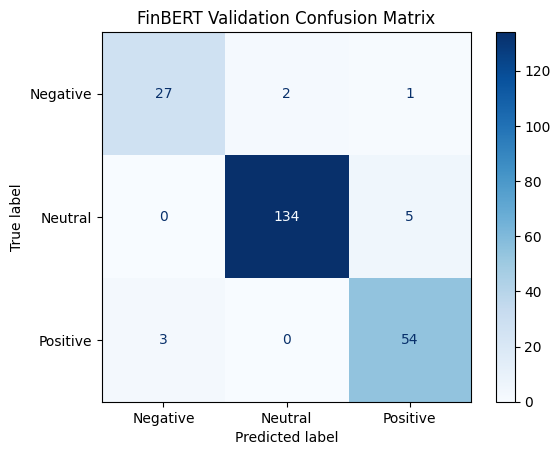

In [41]:
preds_output = trainer.predict(val_dataset)
y_pred = preds_output.predictions.argmax(-1)
print("\nClassification Report:")
print(classification_report(val_labels, y_pred, target_names=["Negative", "Neutral", "Positive"]))

cm = confusion_matrix(val_labels, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Neutral", "Positive"]).plot(cmap='Blues')
plt.title("FinBERT Validation Confusion Matrix")
plt.savefig("finbert_confusion_matrix.png", dpi=150); plt.show()

### 1.7 Save Model

In [44]:
# Save to a new folder 'final_fixed' to bypass the Windows lock
model.save_pretrained("./finbert-finetuned/final_fixed")
tokenizer.save_pretrained("./finbert-finetuned/final_fixed")
print("Successfully saved to ./finbert-finetuned/final_fixed")


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.37it/s]

Successfully saved to ./finbert-finetuned/final_fixed


In [45]:
# Update this line in the next section to use the new folder
finbert_dir = "./finbert-finetuned/final_fixed"


---
## Step 2 – FNSPID News Dataset & Sentiment Scoring
### 2.1 Imports & Config

In [46]:
import os, sys, numpy as np, pandas as pd, torch, torch.nn as nn
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import yfinance as yf
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt, seaborn as sns
from torch.utils.data import Dataset, DataLoader
from datetime import datetime, timedelta
from datasets import load_dataset
import warnings; warnings.filterwarnings('ignore')

from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import AverageTrueRange, BollingerBands

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
STOCKS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
TICKER_MAP = {'GOOG': 'GOOGL'}
REVERSE_TICKER_MAP = {'GOOGL': 'GOOG'}
FEATURE_COLS = [
    'returns', 'rolling_std_20', 'rolling_mean_20', 'rsi', 'macd', 'macd_signal', 'macd_diff',
    'volume_change', 'volume_ratio', 'price_to_ma20', 'high_low_range', 'open_close_diff',
    'ret_5d', 'ret_10d', 'std_5', 'std_10', 'atr_14', 'bb_pct']
LOOKBACK = 30
START_DATE, END_DATE = '2020-01-01', '2024-01-01'
print(f"Device: {DEVICE}")

Device: cpu


### 2.2 Feature Engineering & StackedLSTM

In [47]:
def engineer_features(df):
    df = df.copy()
    c, h, l, o, v = df['Close'], df['High'], df['Low'], df['Open'], df['Volume']
    df['returns'] = c.pct_change(); df['ret_5d'] = c.pct_change(5); df['ret_10d'] = c.pct_change(10)
    df['rolling_std_20'] = df['returns'].rolling(20).std(); df['rolling_mean_20'] = df['returns'].rolling(20).mean()
    df['std_5'] = df['returns'].rolling(5).std(); df['std_10'] = df['returns'].rolling(10).std()
    df['atr_14'] = AverageTrueRange(high=h, low=l, close=c, window=14).average_true_range() / c
    bb = BollingerBands(close=c, window=20, window_dev=2); df['bb_pct'] = bb.bollinger_pband()
    df['rsi'] = RSIIndicator(close=c, window=14).rsi()
    _macd = MACD(close=c); df['macd'] = _macd.macd(); df['macd_signal'] = _macd.macd_signal(); df['macd_diff'] = _macd.macd_diff()
    df['volume_change'] = v.pct_change(); df['volume_ratio'] = v / v.rolling(20).mean()
    df['close_ma20'] = c.rolling(20).mean(); df['price_to_ma20'] = c / df['close_ma20']
    df['high_low_range'] = (h - l) / c; df['open_close_diff'] = (c - o) / o
    df['target'] = (c.shift(-1) > c).astype(int)
    df.replace([np.inf, -np.inf], np.nan, inplace=True); df.dropna(inplace=True)
    return df

class StackedLSTM(nn.Module):
    def __init__(self, input_size, hidden=128, layers=2, dropout=0.35):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers, dropout=dropout, batch_first=True)
        self.bn = nn.BatchNorm1d(hidden); self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 1))
    def forward(self, x):
        out, _ = self.lstm(x); h = self.bn(out[:, -1, :]); h = self.drop(h); return self.head(h).squeeze(-1)

### 2.3 Load FNSPID News Headlines

Using `kasrah/fnspid_financial_news_stock_merged` from HuggingFace — ~3,000 ticker-matched headlines with dates (2019–2023).

In [48]:
print("Loading financial news from kasrah/fnspid_financial_news_stock_merged...")
dataset_tickers = {REVERSE_TICKER_MAP.get(t, t) for t in STOCKS}
ds = load_dataset('kasrah/fnspid_financial_news_stock_merged', split='train', streaming=True)
news_data = []
for r in ds:
    sym = r['Stock_symbol']
    if sym in dataset_tickers:
        yf_ticker = TICKER_MAP.get(sym, sym)
        title = str(r['Article_title']).strip()
        if title and len(title) > 10:
            news_data.append({'Date': str(r['Date'])[:10], 'Ticker': yf_ticker, 'Headline': title})

news_df = pd.DataFrame(news_data)
print(f"Loaded {len(news_df)} headlines")
print(news_df.groupby('Ticker')['Date'].agg(['count', 'min', 'max']))

Loading financial news from kasrah/fnspid_financial_news_stock_merged...
Loaded 2954 headlines
        count         min         max
Ticker                               
AAPL      446  2020-03-09  2023-12-15
AMZN      218  2020-04-27  2023-12-15
GOOGL    1237  2019-01-02  2023-12-15
MSFT      414  2022-04-26  2023-12-15
TSLA      639  2019-07-01  2023-12-15


### 2.4 Score Headlines with FinBERT

In [49]:
finbert_dir = "./finbert-finetuned/final"
if not os.path.exists(finbert_dir):
    print(f"Warning: {finbert_dir} not found. Using pre-trained FinBERT."); finbert_dir = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(finbert_dir)
finbert_model = AutoModelForSequenceClassification.from_pretrained(finbert_dir, ignore_mismatched_sizes=True)
finbert_model.eval()

def get_sentiment(texts, batch_size=64):
    all_scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True, return_tensors='pt', max_length=128)
        with torch.no_grad():
            probs = torch.softmax(finbert_model(**enc).logits, dim=1).numpy()
        all_scores.extend(probs[:, 2] - probs[:, 0])
    return all_scores

print("Scoring headlines...")
news_df['SentimentScore'] = get_sentiment(news_df['Headline'].tolist())
daily_sentiment = news_df.groupby(['Ticker', 'Date'])['SentimentScore'].mean().reset_index()
print(f"Daily sentiment pairs: {len(daily_sentiment)}")
daily_sentiment.head(10)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2050.52it/s]


Scoring headlines...
Daily sentiment pairs: 2954


,Ticker,Date,SentimentScore
0,AAPL,2020-03-09,0.032283
1,AAPL,2020-03-10,0.413385
2,AAPL,2020-03-11,0.189992
3,AAPL,2020-03-12,-0.920888
4,AAPL,2020-03-13,0.984657
5,AAPL,2020-03-16,-0.898162
6,AAPL,2020-03-17,0.982019
7,AAPL,2020-03-18,-0.947485
8,AAPL,2020-03-19,0.693763
9,AAPL,2020-03-20,0.978349


---
## Step 3 – Sentiment-Technical Fusion
### 3.1 Fetch Price Data

In [50]:
print(f"Fetching price data ({START_DATE} to {END_DATE})...")
raw_prices = {}
for t in STOCKS:
    df_p = yf.download(t, start=START_DATE, end=END_DATE, progress=False)
    if isinstance(df_p.columns, pd.MultiIndex): df_p.columns = [c[0] for c in df_p.columns]
    if len(df_p) > 20:
        raw_prices[t] = df_p; print(f"  {t}: {len(df_p)} days")
    else:
        print(f"  Warning: {t} skipped (insufficient data: {len(df_p)} days)")
processed = {t: engineer_features(df_p) for t, df_p in raw_prices.items()}
if not processed: raise ValueError("No valid price data downloaded.")

Fetching price data (2020-01-01 to 2024-01-01)...
  AAPL: 1006 days
  MSFT: 1006 days
  GOOGL: 1006 days
  AMZN: 1006 days
  TSLA: 1006 days


### 3.2 Build Fused Dataset

In [51]:
X_fused, y_true, S_fused, dates, tickers_list = [], [], [], [], []
scaler = RobustScaler()

all_X = []
for t, df_p in processed.items():
    feat = df_p[FEATURE_COLS].values
    for i in range(LOOKBACK, len(feat)): all_X.append(feat[i-LOOKBACK:i])
all_X = np.array(all_X)
n_f = all_X.shape[2]; scaler.fit(all_X.reshape(-1, n_f))

for t, df_p in processed.items():
    feat, target, idx = df_p[FEATURE_COLS].values, df_p['target'].values, df_p.index
    for i in range(LOOKBACK, len(feat)):
        cur_date = str(idx[i].date())
        sent = daily_sentiment[(daily_sentiment['Ticker'] == t) & (daily_sentiment['Date'] == cur_date)]
        if not sent.empty:
            seq = scaler.transform(feat[i-LOOKBACK:i].reshape(-1, n_f)).reshape(-1, LOOKBACK, n_f)
            X_fused.append(seq[0]); y_true.append(target[i])
            S_fused.append(sent['SentimentScore'].values[0]); dates.append(cur_date); tickers_list.append(t)

X_fused = np.array(X_fused, dtype=np.float32); y_true = np.array(y_true, dtype=np.float32)
S_fused = np.array(S_fused, dtype=np.float32)
print(f"Overlapping samples: {len(X_fused)}")
print(f"Per ticker: {pd.Series(tickers_list).value_counts().to_dict()}")

Overlapping samples: 2439
Per ticker: {'GOOGL': 927, 'TSLA': 452, 'AAPL': 428, 'MSFT': 414, 'AMZN': 218}


### 3.3 FusionLSTM & Training

In [52]:
class FusionLSTM(nn.Module):
    def __init__(self, pretrained_lstm):
        super().__init__()
        self.lstm = pretrained_lstm.lstm; self.bn = pretrained_lstm.bn; self.drop = pretrained_lstm.drop
        for p in self.lstm.parameters(): p.requires_grad = False
        for p in self.bn.parameters(): p.requires_grad = False
        self.head = nn.Sequential(nn.Linear(129, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1))
    def forward(self, x_tech, x_sent):
        out, _ = self.lstm(x_tech); h = self.drop(self.bn(out[:, -1, :]))
        return self.head(torch.cat([h, x_sent.unsqueeze(-1)], dim=1)).squeeze(-1)

baseline = StackedLSTM(input_size=18).to(DEVICE)
try:
    ckpt = torch.load('lstm_p08_v3.pt', map_location=DEVICE, weights_only=False)
    baseline.load_state_dict(ckpt['model_state_dict']); print("Baseline loaded.")
except Exception as e:
    print(f"Could not load baseline: {e}. Using random init.")

fusion_model = FusionLSTM(baseline).to(DEVICE)
num_pos = y_true.sum()
num_neg = len(y_true) - num_pos
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(DEVICE)
optimizer = torch.optim.AdamW(fusion_model.head.parameters(), lr=0.005, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
X_t = torch.tensor(X_fused).to(DEVICE); S_t = torch.tensor(S_fused).to(DEVICE); y_t = torch.tensor(y_true).to(DEVICE)

fusion_model.train()
for ep in range(80):
    optimizer.zero_grad(); loss = criterion(fusion_model(X_t, S_t), y_t); loss.backward(); optimizer.step(); scheduler.step()
    if (ep+1) % 10 == 0: print(f"  Epoch {ep+1}/80  Loss: {loss.item():.4f}")
print("Fusion training complete.")

Baseline loaded.
  Epoch 10/80  Loss: 0.6452
  Epoch 20/80  Loss: 0.6423
  Epoch 30/80  Loss: 0.6414
  Epoch 40/80  Loss: 0.6412
  Epoch 50/80  Loss: 0.6398
  Epoch 60/80  Loss: 0.6441
  Epoch 70/80  Loss: 0.6356
  Epoch 80/80  Loss: 0.6377
Fusion training complete.


---
## Step 4 – Baseline vs Fusion Comparison
### 4.1 Metrics

In [56]:
fusion_model.eval(); baseline.eval()
with torch.no_grad():
    base_probs = torch.sigmoid(baseline(X_t)).cpu().numpy()
    fusion_probs = torch.sigmoid(fusion_model(X_t, S_t)).cpu().numpy()

best_thresh_base = 0.50
best_f1_base = 0
for t in np.arange(0.40, 0.60, 0.01):
    p = (base_probs > t).astype(int)
    score = f1_score(y_true, p, average='macro')
    if score > best_f1_base:
        best_f1_base = score
        best_thresh_base = t

best_thresh_fuse = 0.50
best_f1_fuse = 0
for t in np.arange(0.40, 0.60, 0.01):
    p = (fusion_probs > t).astype(int)
    score = f1_score(y_true, p, average='macro')
    if score > best_f1_fuse:
        best_f1_fuse = score
        best_thresh_fuse = t

base_preds = (base_probs > best_thresh_base).astype(int)
fuse_preds = (fusion_probs > best_thresh_fuse).astype(int)

print("--- BASELINE LSTM ---")
print(f"Optimal Threshold: {best_thresh_base:.2f}")
try:
    print(f"Accuracy: {accuracy_score(y_true, base_preds):.4f}")
    print(classification_report(y_true, base_preds, zero_division=0))
except Exception: pass
print("\n--- FUSION LSTM ---")
print(f"Optimal Threshold: {best_thresh_fuse:.2f}")
try:
    print(f"Accuracy: {accuracy_score(y_true, fuse_preds):.4f}")
    print(classification_report(y_true, fuse_preds, zero_division=0))
except Exception: pass

--- BASELINE LSTM ---
Optimal Threshold: 0.50
Accuracy: 0.5297
              precision    recall  f1-score   support

         0.0       0.50      0.46      0.48      1137
         1.0       0.56      0.59      0.57      1302

    accuracy                           0.53      2439
   macro avg       0.53      0.53      0.52      2439
weighted avg       0.53      0.53      0.53      2439


--- FUSION LSTM ---
Optimal Threshold: 0.50
Accuracy: 0.5605
              precision    recall  f1-score   support

         0.0       0.52      0.62      0.57      1137
         1.0       0.60      0.51      0.55      1302

    accuracy                           0.56      2439
   macro avg       0.56      0.56      0.56      2439
weighted avg       0.57      0.56      0.56      2439



### 4.2 Correlation Heatmap

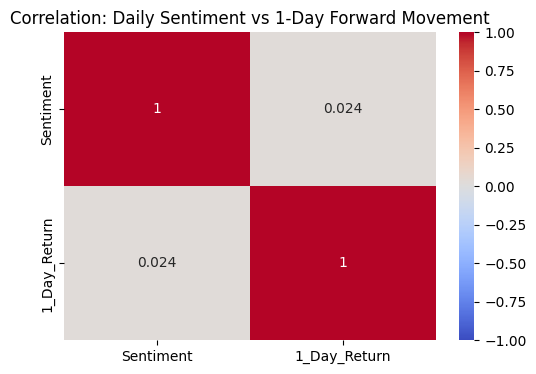

In [54]:
df_corr = pd.DataFrame({'Sentiment': S_fused, '1_Day_Return': y_true})
plt.figure(figsize=(6, 4))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation: Daily Sentiment vs 1-Day Forward Movement")
plt.savefig('sentiment_correlation.png', dpi=150); plt.show()

### 4.3 Confusion Matrices

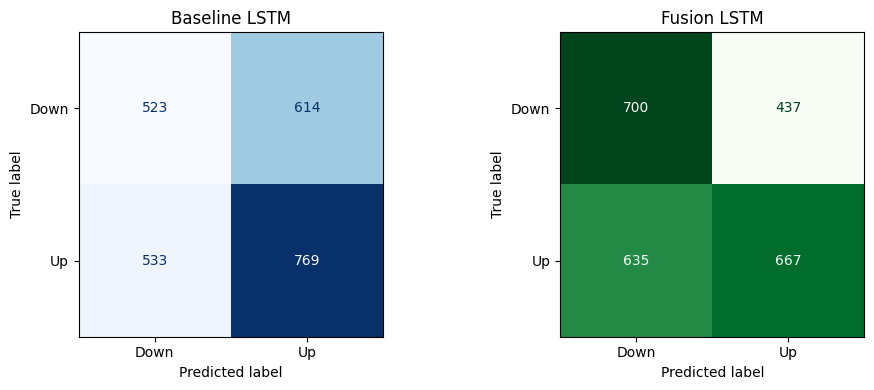

Done!


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
try: ConfusionMatrixDisplay(confusion_matrix(y_true, base_preds), display_labels=['Down','Up']).plot(ax=axes[0], cmap='Blues', colorbar=False)
except: pass
axes[0].set_title('Baseline LSTM')
try: ConfusionMatrixDisplay(confusion_matrix(y_true, fuse_preds), display_labels=['Down','Up']).plot(ax=axes[1], cmap='Greens', colorbar=False)
except: pass
axes[1].set_title('Fusion LSTM')
plt.tight_layout(); plt.savefig('fusion_confusion_matrix.png', dpi=150); plt.show()
print("Done!")